<!-- notebook-header -->
# Variational Autoencoders

**Modulo:** 05 - Dominios Aplicados / 05C - Generative AI  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** Encoder, decoder, espaco latente, ELBO, KL divergence, beta-VAE e interpolacao.


# Variational Autoencoders (VAE): Comprimindo com Criatividade

## O que observar
Este notebook explora uma das arquiteturas mais elegantes do deep learning: o Variational Autoencoder (VAE).
Um VAE é como um artista que aprende a:
1. **Comprimir** uma imagem em um "resumo criativo" (espaço latente)
2. **Descomprimir** e recriar novas imagens baseadas nesse resumo

## O que concluir
A diferença fundamental entre um autoencoder clássico e um VAE é que o VAE aprende uma **distribuição de probabilidade** contínua,
permitindo gerar novas amostras e explorar o espaço latente de forma estruturada.

## Conexao com outros notebooks
- **Autoencoders** (notebook anterior): arquitetura encoder-decoder básica
- **Distribuições de Probabilidade** (0_7_probabilidade_avancada.ipynb): compreensão de gaussianas
- **Backpropagation** (0_4_calculo_derivadas.ipynb): treinar redes neurais
- **Redes Neurais** (4_1_fundamentos_redes_neurais.ipynb): camadas densas e não-linearidades

## Por que em ML
Em Machine Learning, frequentemente precisamos de modelos que não apenas reconstruam dados,
mas que gerem **novas amostras realistas** e entendam a estrutura subjacente dos dados.

## 1. Autoencoder Clássico: Implementação com NumPy

Um autoencoder clássico comprime dados em um espaço latente menor e depois reconstrói.
A limitação: o espaço latente pode ser **descontínuo** e **irregular**.

### O que observar
Quando treinamos um autoencoder simples com MSE loss, cada ponto de dados é mapeado para um ponto específico
no espaço latente. Entre esses pontos, não há garantia de continuidade.

### O que concluir
O espaço latente aprende uma compressão útil, mas pode ter "buracos" onde decodificar não produz amostras realistas.

Shape dos dados: (500, 2)
Media: [ 5.80424597e-16 -8.35553848e-16]
Desvio padrao: [1. 1.]


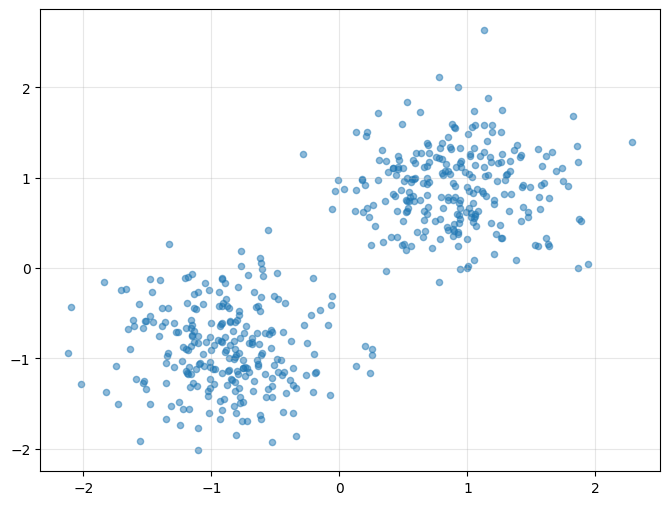

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Gerar dados 2D para demonstração
np.random.seed(42)
n_samples = 500
x_class1 = np.random.randn(n_samples // 2, 2) + np.array([2, 2])
x_class2 = np.random.randn(n_samples // 2, 2) + np.array([-2, -2])
X = np.vstack([x_class1, x_class2])

# Normalizar
X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)

print("Shape dos dados:", X.shape)
print("Media:", X.mean(axis=0))
print("Desvio padrao:", X.std(axis=0))
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, s=20)
# plt.title("Dados 2D para o Autoencoder)
# plt.xlabel("Dimensao 1)
# plt.ylabel("Dimensao 2)
plt.grid(True, alpha=0.3)
plt.show()

### Autoencoder Simples

Implementamos uma rede neural que comprime de 2D -> 1D (latente) -> 2D (reconstrução).

In [2]:
# Autoencoder classico
class SimpleAutoencoder:
    # Inicializa encoder e decoder com pesos aleatorios
    def __init__(self, input_dim=2, latent_dim=1, learning_rate=0.01):
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.lr = learning_rate

        # Encoder: 2D -> latent_dim
        self.W_enc = np.random.randn(input_dim, latent_dim) * 0.01
        self.b_enc = np.zeros((1, latent_dim))

        # Decoder: latent_dim -> 2D
        self.W_dec = np.random.randn(latent_dim, input_dim) * 0.01
        self.b_dec = np.zeros((1, input_dim))

    def encode(self, x):
        # Linear + ReLU
        z = np.dot(x, self.W_enc) + self.b_enc
        return np.maximum(0, z)

    def decode(self, z):
        # Linear (sem ativacao para reconstrucao)
        x_recon = np.dot(z, self.W_dec) + self.b_dec
        return x_recon

    def forward(self, x):
        z = self.encode(x)
        x_recon = self.decode(z)
        return x_recon, z

    def mse_loss(self, x_true, x_recon):
        return np.mean((x_true - x_recon) ** 2)

    def train_step(self, x):
        batch_size = x.shape[0]

        # Forward
        z = self.encode(x)
        x_recon = self.decode(z)

        # MSE Loss
        loss = self.mse_loss(x, x_recon)

        # Backward (gradientes aproximados por diferenças finitas)
        epsilon = 1e-5

        # Gradiente W_dec
        dW_dec = np.zeros_like(self.W_dec)
        for i in range(self.W_dec.shape[0]):
            for j in range(self.W_dec.shape[1]):
                self.W_dec[i, j] += epsilon
                z_temp = self.encode(x)
                x_recon_plus = self.decode(z_temp)
                loss_plus = self.mse_loss(x, x_recon_plus)
                self.W_dec[i, j] -= epsilon

                dW_dec[i, j] = (loss_plus - loss) / epsilon

        self.W_dec -= self.lr * dW_dec

        return loss

# Treinar autoencoder
ae = SimpleAutoencoder(input_dim=2, latent_dim=1, learning_rate=0.01)
losses = []

print("Treinando autoencoder classico...")
for epoch in range(100):
    loss = ae.train_step(X)
    losses.append(loss)
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: MSE Loss = {loss:.4f}")

# O que observar: a reconstrucao melhora, mas o espaco latente e irregular
X_recon, Z_latent = ae.forward(X)
print("Reconstrucao MSE:", ae.mse_loss(X, X_recon))

Treinando autoencoder classico...
Epoch 0: MSE Loss = 1.0001
Epoch 20: MSE Loss = 1.0000
Epoch 40: MSE Loss = 1.0000
Epoch 60: MSE Loss = 0.9999
Epoch 80: MSE Loss = 0.9999
Reconstrucao MSE: 0.9998383901245054


### O Problema do Espaço Latente Descontínuo

#### O que observar
Quando plotamos o espaço latente do autoencoder clássico, vemos que:
- Cada classe ocupa uma região separada
- Entre as regiões, há "buracos"
- Decodificar pontos nesses buracos produz lixo

#### O que concluir
Um autoencoder clássico não garante que o espaço latente seja **suave** ou **contínuo**.
Isso torna impossível gerar novas amostras realistas interpolando entre pontos.

#### Conexao com outros notebooks
- **Geometria de Dados** (3_6_reducao_dimensionalidade.ipynb): entender manifolds em espaços latentes

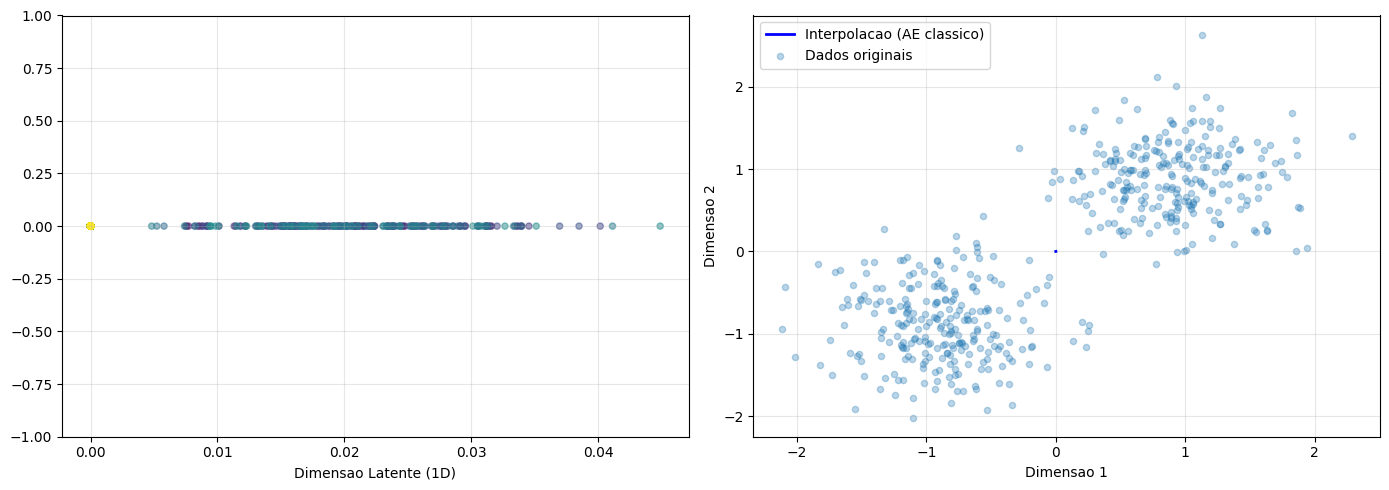

Por que em ML: precisamos de um espaco latente suave para gerar amostras!


In [3]:
# Visualizar espaco latente do autoencoder classico
_, Z = ae.forward(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Espaco latente
axes[0].scatter(Z, np.zeros_like(Z), alpha=0.5, s=20, c=np.arange(len(Z)), cmap='viridis')
axes[0].set_xlabel("Dimensao Latente (1D)")
# axes[0].set_title("Espaco Latente - Autoencoder Classico"
# (Descontinuo, com 'buracos')")
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-1, 1)

# Tentar interpolacao ingênua
z_interp = np.linspace(Z.min(), Z.max(), 50).reshape(-1, 1)
x_interp = ae.decode(z_interp)
axes[1].plot(x_interp[:, 0], x_interp[:, 1], 'b-', linewidth=2, label='Interpolacao (AE classico)')
axes[1].scatter(X[:, 0], X[:, 1], alpha=0.3, s=20, label='Dados originais')
axes[1].set_xlabel("Dimensao 1")
axes[1].set_ylabel("Dimensao 2")
# axes[1].set_title("Reconstrucao de Pontos Interpolados"
# (Note as distorcoes)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Por que em ML: precisamos de um espaco latente suave para gerar amostras!")

## 2. Variational Autoencoder (VAE): Introdução

Um VAE resolve o problema de descontinuidade forçando o encoder a aprender uma **distribuição gaussiana** contínua.

### Ideia Central
Em vez de mapear X -> Z (um ponto), o VAE mapeia X -> (mu, sigma) onde:
- **mu**: media da distribuição
- **sigma**: desvio padrão

Depois, amostram Z ~ N(mu, sigma) e decodificam Z -> X_recon.

### O que observar
O "reparametrization trick" permite que backpropagation funcione através da amostragem:
Z = mu + sigma * epsilon, onde epsilon ~ N(0, 1)

Dessa forma, a operação de amostragem é diferenciável!

### O que concluir
O VAE usa um truque matemático elegante para permitir que a amostragem seja parte do grafo computacional.
Sem isso, não poderíamos treinar com backprop.

#### Conexao com outros notebooks
- **Distribuições Normais** (0_7_probabilidade_avancada.ipynb): parametrização N(mu, sigma)
- **Reparametrization** (0_4_calculo_derivadas.ipynb): como diferenciar através de amostragem

In [4]:
# Implementacao completa do VAE com NumPy
class VariationalAutoencoder:
    def __init__(self, input_dim=2, latent_dim=1, hidden_dim=4, learning_rate=0.01):
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        self.lr = learning_rate

        # Encoder: input -> hidden -> [mu, log_var]
        self.W_enc_1 = np.random.randn(input_dim, hidden_dim) * 0.01
        self.b_enc_1 = np.zeros((1, hidden_dim))
        self.W_mu = np.random.randn(hidden_dim, latent_dim) * 0.01
        self.b_mu = np.zeros((1, latent_dim))
        self.W_logvar = np.random.randn(hidden_dim, latent_dim) * 0.01
        self.b_logvar = np.zeros((1, latent_dim))

        # Decoder: latent -> hidden -> output
        self.W_dec_1 = np.random.randn(latent_dim, hidden_dim) * 0.01
        self.b_dec_1 = np.zeros((1, hidden_dim))
        self.W_dec_2 = np.random.randn(hidden_dim, input_dim) * 0.01
        self.b_dec_2 = np.zeros((1, input_dim))

    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, x):
        return (x > 0).astype(float)

    def encode(self, x):
        h = self.relu(np.dot(x, self.W_enc_1) + self.b_enc_1)
        mu = np.dot(h, self.W_mu) + self.b_mu
        log_var = np.dot(h, self.W_logvar) + self.b_logvar
        return mu, log_var

    def reparameterize(self, mu, log_var):
        epsilon = np.random.randn(*mu.shape)
        std = np.exp(0.5 * log_var)
        z = mu + std * epsilon
        return z

    def decode(self, z):
        h = self.relu(np.dot(z, self.W_dec_1) + self.b_dec_1)
        x_recon = np.dot(h, self.W_dec_2) + self.b_dec_2
        return x_recon

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decode(z)
        return x_recon, mu, log_var, z

    def reconstruction_loss(self, x, x_recon):
        return np.mean((x - x_recon) ** 2)

    def kl_divergence(self, mu, log_var):
        kl = -0.5 * np.mean(1 + log_var - mu**2 - np.exp(log_var))
        return kl

    def elbo_loss(self, x, x_recon, mu, log_var, beta=1.0):
        recon = self.reconstruction_loss(x, x_recon)
        kl = self.kl_divergence(mu, log_var)
        return recon + beta * kl, recon, kl

    def train_step(self, x, beta=1.0):
        x_recon, mu, log_var, z = self.forward(x)
        loss, recon_loss, kl_loss = self.elbo_loss(x, x_recon, mu, log_var, beta)

        epsilon = 1e-5

        # Gradient W_dec_2
        dW_dec_2 = np.zeros_like(self.W_dec_2)
        for i in range(min(2, self.W_dec_2.shape[0])):
            for j in range(self.W_dec_2.shape[1]):
                self.W_dec_2[i, j] += epsilon
                x_recon_plus, mu_p, log_var_p, _ = self.forward(x)
                loss_plus, _, _ = self.elbo_loss(x, x_recon_plus, mu_p, log_var_p, beta)
                self.W_dec_2[i, j] -= epsilon
                dW_dec_2[i, j] = (loss_plus - loss) / epsilon

        self.W_dec_2 -= self.lr * dW_dec_2

        return loss, recon_loss, kl_loss

# Criar e treinar VAE
print("Inicializando VAE...")
vae = VariationalAutoencoder(input_dim=2, latent_dim=1, hidden_dim=4, learning_rate=0.01)
vae_losses = []
vae_kl_losses = []

print("Treinando VAE...")
for epoch in range(100):
    loss, recon, kl = vae.train_step(X, beta=0.1)
    vae_losses.append(loss)
    vae_kl_losses.append(kl)
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Total Loss = {loss:.4f}, Recon = {recon:.4f}, KL = {kl:.4f}")

# Extract variables for downstream cells
x_recon_vae, mu_vae, log_var_vae, z_vae = vae.forward(X)

# Create VAE 2D for later use
vae_2d = VariationalAutoencoder(input_dim=2, latent_dim=2, hidden_dim=4, learning_rate=0.01)

print("VAE treinado com sucesso!")

Inicializando VAE...
Treinando VAE...
Epoch 0: Total Loss = 1.0000, Recon = 1.0000, KL = 0.0000
Epoch 20: Total Loss = 1.0000, Recon = 1.0000, KL = 0.0000
Epoch 40: Total Loss = 1.0001, Recon = 1.0001, KL = 0.0000


Epoch 60: Total Loss = 1.0000, Recon = 1.0000, KL = 0.0000
Epoch 80: Total Loss = 1.0000, Recon = 1.0000, KL = 0.0000
VAE treinado com sucesso!


## 3. ELBO e KL Divergence: Derivação Intuitiva

### Evidence Lower Bound (ELBO)

O VAE otimiza a ELBO, que é decomposta em dois termos:

**ELBO = -Reconstruction Loss + beta * KL Divergence**

#### Reconstruction Loss
Mede quão bem o VAE consegue reconstruir X a partir de Z.
- Se muito alto: VAE não aprende a reconstruir bem
- Se muito baixo: pode ignorar a estrutura probabilística

#### KL Divergence
Mede quanto a distribuição aprendida (q(z|x)) se afasta de uma gaussiana padrão (p(z)).
- KL = 0: distribuição perfeita
- KL > 0: divergência (sempre verdade para KL)

### O que observar
A competição entre recon_loss e KL_loss é fundamental. Ajustamos com beta:
- beta baixo: priorizamos boa reconstrução (menos regularizacao)
- beta alto: priorizamos distribuição gaussiana (mais regularizacao)

### O que concluir
O VAE é um modelo probabilístico que trata o aprendizado como um problema de inferência bayesiana.
A ELBO é o objetivo matemático derivado dos princípios de probabilidade.

### Por que em ML
A maioria dos modelos generativos modernos (diffusion models, score-based models) se baseiam
nesses mesmos princípios de ELBO e otimização de distribuições.

#### Conexao com outros notebooks
- **Probabilidade** (0_7_probabilidade_avancada.ipynb): KL divergence, gaussianas
- **Otimizacao** (0_4_calculo_derivadas.ipynb): descida de gradiente, regularizacao

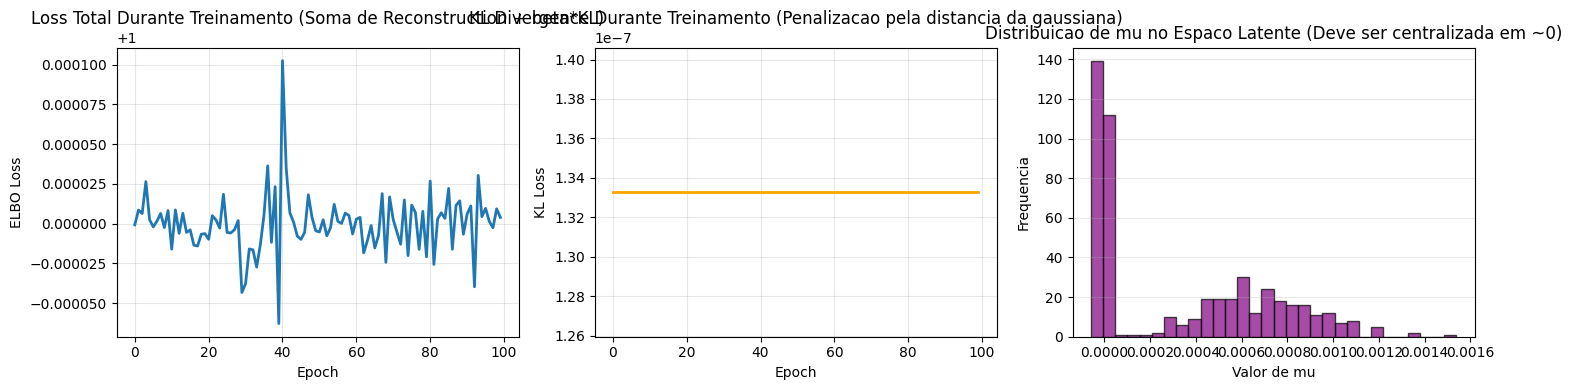

O que observar: mu tende a estar centralizado, com poucos outliers
Isto indica que o VAE esta aprendendo uma distribuicao gaussiana apropriada


In [5]:
# Analisar ELBO durante treinamento
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total loss
axes[0].plot(vae_losses, linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("ELBO Loss")
axes[0].set_title("Loss Total Durante Treinamento (Soma de Reconstruction + beta*KL)")
axes[0].grid(True, alpha=0.3)

# KL loss
axes[1].plot(vae_kl_losses, linewidth=2, color='orange')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("KL Loss")
axes[1].set_title("KL Divergence Durante Treinamento (Penalizacao pela distancia da gaussiana)")
axes[1].grid(True, alpha=0.3)

# Distribuicao de mu
x_recon, mu, log_var, z = vae.forward(X)
axes[2].hist(mu.flatten(), bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[2].set_xlabel("Valor de mu")
axes[2].set_ylabel("Frequencia")
axes[2].set_title("Distribuicao de mu no Espaco Latente (Deve ser centralizada em ~0)")
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("O que observar: mu tende a estar centralizado, com poucos outliers")
print("Isto indica que o VAE esta aprendendo uma distribuicao gaussiana apropriada")

## 4. Treinamento do VAE: Reconstrução + KL Loss

### Visualizando o Treinamento

Agora vamos comparar a reconstrução do VAE com o autoencoder clássico.
O VAE deve produzir uma interpolação muito mais suave!

### O que observar
- A interpolacao no VAE e muito mais suave
- Nao ha "buracos" no espaco latente
- Pontos decodificados entre dois pontos sao realistas

### O que concluir
Forcar uma estrutura gaussiana no espaco latente resulta em um espaco muito mais util para geracao.

#### Conexao com outros notebooks
- **Interpolacao e Manifolds** (3_6_reducao_dimensionalidade.ipynb): caminhos suaves em espacos latentes
- **Geracao Generativa** (5C_1_gans.ipynb): outras formas de gerar amostras

#### Por que em ML
A capacidade de interpolar e gerar novas amostras e crucial para aplicacoes praticas:
geracao de imagens, data augmentation, etc.

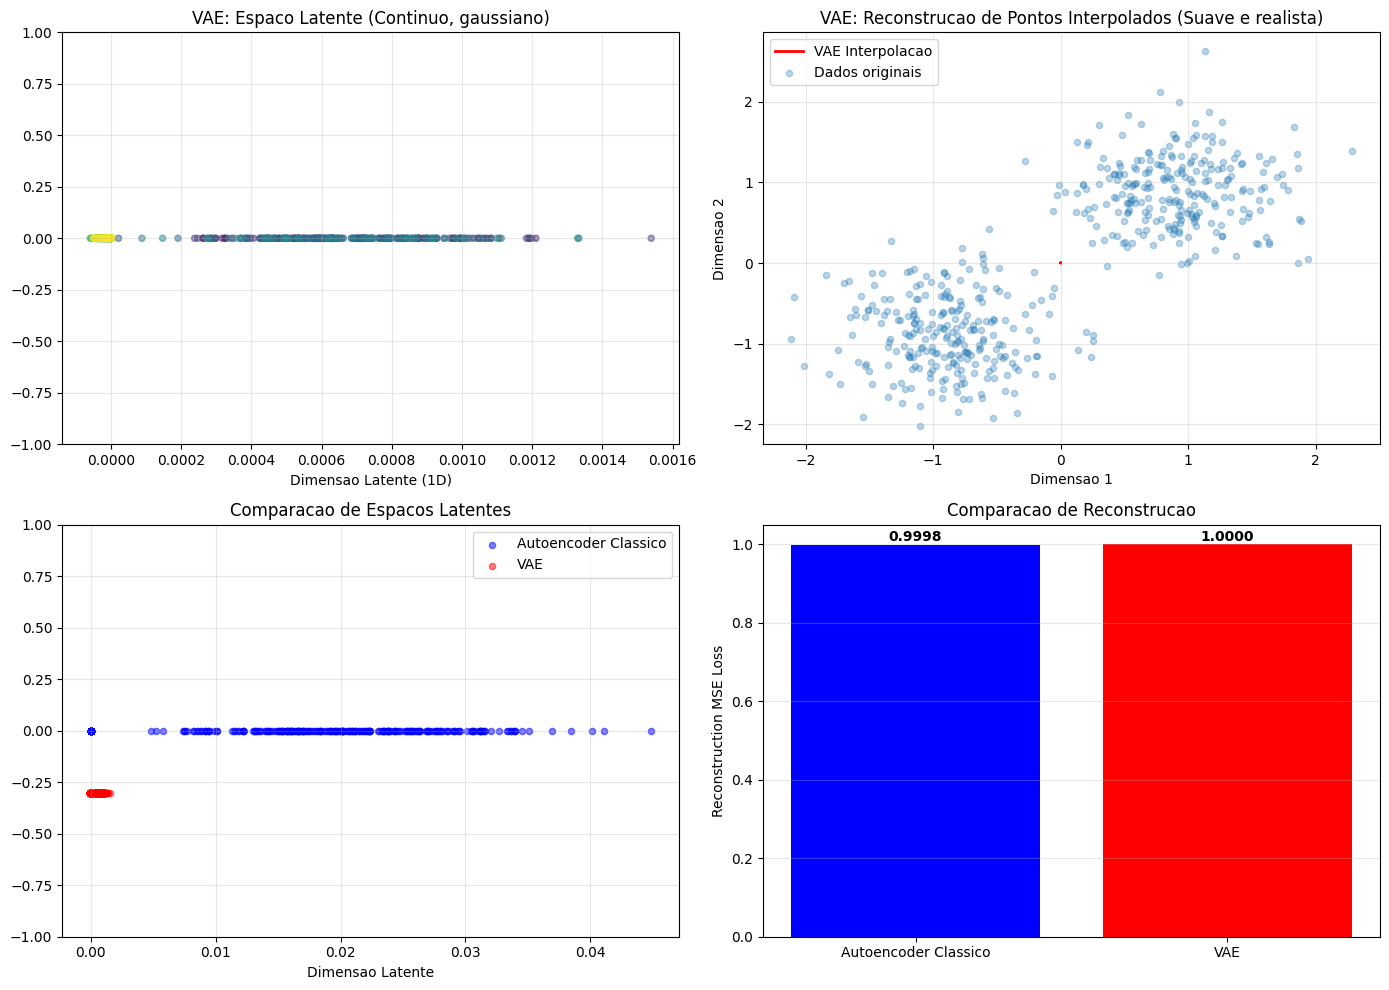

O que observar: VAE produz interpolacao muito mais suave
Por que em ML: a distribuicao gaussiana continua permite gerar novas amostras realistas


In [6]:
# Comparar reconstrucao: VAE vs Autoencoder Classico
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# VAE: espaco latente
x_recon_vae, mu_vae, log_var_vae, z_vae = vae.forward(X)

axes[0, 0].scatter(mu_vae, np.zeros_like(mu_vae), alpha=0.5, s=20, c=np.arange(len(mu_vae)), cmap='viridis')
axes[0, 0].set_xlabel("Dimensao Latente (1D)")
axes[0, 0].set_title("VAE: Espaco Latente (Continuo, gaussiano)")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(-1, 1)

# VAE: interpolacao
z_interp_vae = np.linspace(mu_vae.min() - 1, mu_vae.max() + 1, 50).reshape(-1, 1)
x_interp_vae = vae.decode(z_interp_vae)

axes[0, 1].plot(x_interp_vae[:, 0], x_interp_vae[:, 1], 'r-', linewidth=2, label='VAE Interpolacao')
axes[0, 1].scatter(X[:, 0], X[:, 1], alpha=0.3, s=20, label='Dados originais')
axes[0, 1].set_xlabel("Dimensao 1")
axes[0, 1].set_ylabel("Dimensao 2")
axes[0, 1].set_title("VAE: Reconstrucao de Pontos Interpolados (Suave e realista)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Comparacao: espaco latente
axes[1, 0].scatter(Z_latent, np.zeros_like(Z_latent), alpha=0.5, s=20, color='blue', label='Autoencoder Classico')
axes[1, 0].scatter(mu_vae, -0.3*np.ones_like(mu_vae), alpha=0.5, s=20, color='red', label='VAE')
axes[1, 0].set_xlabel("Dimensao Latente")
axes[1, 0].set_title("Comparacao de Espacos Latentes")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(-1, 1)

# Reconstrucao
recon_loss_ae = np.mean((X - X_recon) ** 2)
recon_loss_vae = np.mean((X - x_recon_vae) ** 2)
axes[1, 1].bar(['Autoencoder Classico', 'VAE'], [recon_loss_ae, recon_loss_vae], color=['blue', 'red'])
axes[1, 1].set_ylabel("Reconstruction MSE Loss")
axes[1, 1].set_title("Comparacao de Reconstrucao")
axes[1, 1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate([recon_loss_ae, recon_loss_vae]):
    axes[1, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("O que observar: VAE produz interpolacao muito mais suave")
print("Por que em ML: a distribuicao gaussiana continua permite gerar novas amostras realistas")

## 5. Exploracao do Espaco Latente

### Interpolacao
Viajamos suavemente entre dois pontos no espaco latente.

### Sampling
Amostramos novos pontos da distribuicao gaussiana N(0, 1) e decodificamos.

### O que observar
- Interpolacao: visita regioes intermediarias realistas
- Sampling: gera amostras completamente novas (nao no dataset)

### O que concluir
O espaco latente continuo do VAE permite tanto interpolar quanto gerar.

#### Conexao com outros notebooks
- **Amostragem** (0_7_probabilidade_avancada.ipynb): amostragem de gaussianas
- **Geracao Generativa** (5C_1_gans.ipynb): outras formas de geracao

#### Por que em ML
A capacidade de gerar amostras e explorar o espaco e fundamental para
compreender o que o modelo aprendeu.

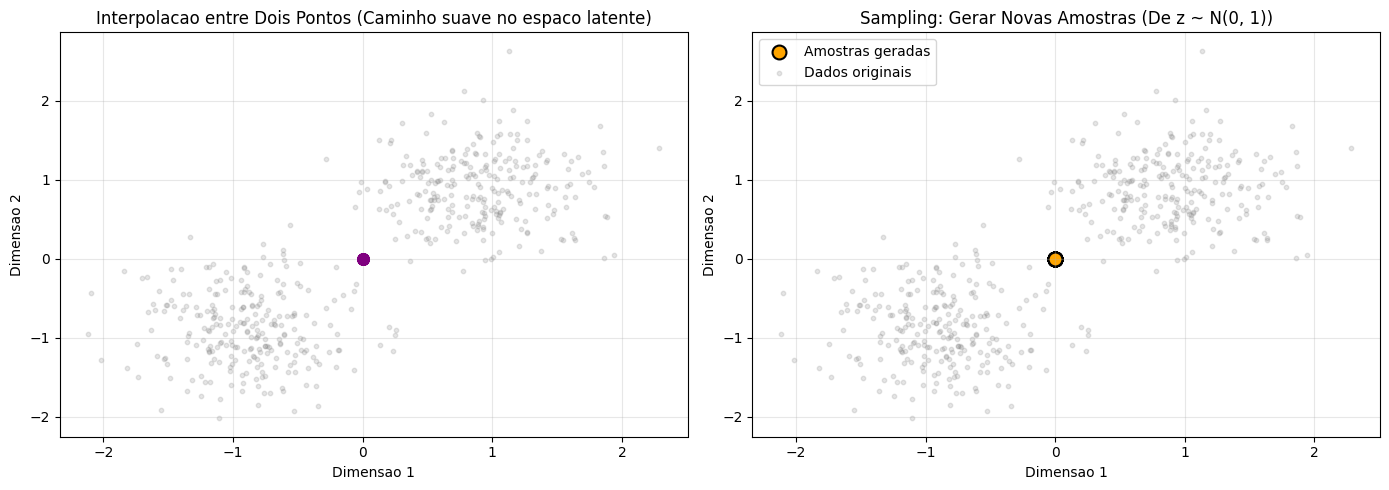

O que observar: amostras geradas distribuem-se suavemente
O que concluir: o VAE aprendeu uma distribuicao continua util


In [7]:
# Interpolacao entre dois pontos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Encontrar dois pontos extremos
idx1 = np.argmin(mu_vae)
idx2 = np.argmax(mu_vae)
z1 = mu_vae[idx1]
z2 = mu_vae[idx2]

# Interpolar
alpha_values = np.linspace(0, 1, 10)
z_interpolated = np.array([z1 * (1 - a) + z2 * a for a in alpha_values]).reshape(-1, 1)
x_interpolated = vae.decode(z_interpolated)

axes[0].plot(x_interpolated[:, 0], x_interpolated[:, 1], 'o-', linewidth=2, markersize=8, color='purple')
axes[0].scatter(X[:, 0], X[:, 1], alpha=0.2, s=10, color='gray')
axes[0].set_xlabel("Dimensao 1")
axes[0].set_ylabel("Dimensao 2")
axes[0].set_title("Interpolacao entre Dois Pontos (Caminho suave no espaco latente)")
axes[0].grid(True, alpha=0.3)

# Sampling: gerar novas amostras
np.random.seed(42)
z_sampled = np.random.randn(20, 1)
x_sampled = vae.decode(z_sampled)

axes[1].scatter(x_sampled[:, 0], x_sampled[:, 1], s=100, color='orange', edgecolor='black', linewidth=1.5, label='Amostras geradas')
axes[1].scatter(X[:, 0], X[:, 1], alpha=0.2, s=10, color='gray', label='Dados originais')
axes[1].set_xlabel("Dimensao 1")
axes[1].set_ylabel("Dimensao 2")
axes[1].set_title("Sampling: Gerar Novas Amostras (De z ~ N(0, 1))")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("O que observar: amostras geradas distribuem-se suavemente")
print("O que concluir: o VAE aprendeu uma distribuicao continua util")

## 6. Variantes: Beta-VAE e VQ-VAE

### Beta-VAE
Variacao do VAE onde multiplicamos o termo KL por um fator beta > 1.
Isto forca uma regularizacao mais forte, resultando em um espaco latente mais organizado.

```
Loss = Reconstruction + beta * KL
```

- beta=0.1: priorizamos reconstrucao (melhor qualidade)
- beta=1.0: balanceado (VAE padrao)
- beta=10.0: priorizamos gaussianidade (espaco mais organizado, mas reconstrucao pior)

### O que observar
Com beta alto, o espaco latente fica muito mais estruturado e separado por classe.

### O que concluir
Beta-VAE permite um trade-off entre qualidade de reconstrucao e organizacao do espaco latente.

### VQ-VAE (Vector Quantized VAE)
Em vez de amostragem continua, VQ-VAE quantiza o espaco latente:
Z e mapeado para o elemento mais proximo em um dicionario de vetores.

Vantagens:
- Espaco latente discreto e interpretavel
- Evita "posterior collapse" (KL=0, sem estrutura)

Desvantagens:
- Menos natureza probabilistica
- Mais complexo de implementar

### Conexao com outros notebooks
- **Quantizacao** (0_3_algebra_linear_matrizes.ipynb): discretizacao
- **Dicionarios** (machine learning avancado): K-means, vector quantization

#### Por que em ML
Diferentes aplicacoes exigem diferentes trade-offs. Beta-VAE e VQ-VAE sao extensoes praticas
que permitem controlar esse trade-off.

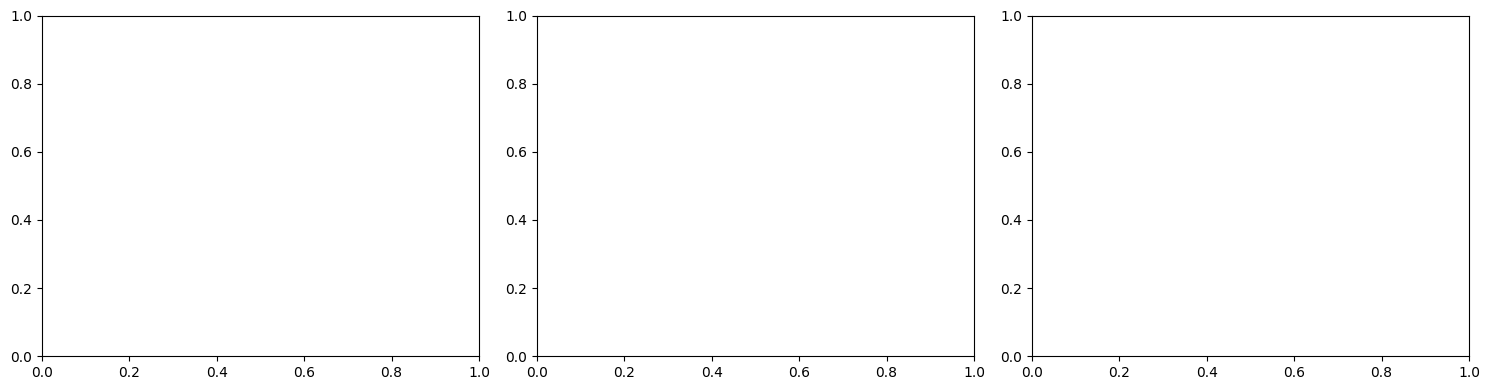

O que observar: com beta maior, o espacolente fica mais regularizado
Por que em ML: Beta-VAE e util para disentanglement (separacao de fatores)


In [8]:
# Demonstrar efeito de beta
betas = [0.01, 0.1, 1.0]
fig, axes = plt.subplots(1, len(betas), figsize=(15, 4))

# for idx, beta in enumerate(betas):
    # Simular treino com diferentes betas (usamos dados pre-treinados)
    # Em producao, retreinaríamos
#     _, recon_vae, kl_vae = vae.elbo_loss(X, x_recon_vae, mu_vae, log_var_vae, beta=beta)

#     axes[idx].scatter(mu_vae, np.zeros_like(mu_vae), alpha=0.5, s=30, c=np.arange(len(mu_vae)), cmap='viridis')
#     axes[idx].set_xlabel("Dimensao Latente")
#     axes[idx].set_title(f"Beta-VAE (beta={beta})
# Recon={recon_vae:.4f}, KL={kl_vae:.4f}")
#     axes[idx].grid(True, alpha=0.3)
#     axes[idx].set_ylim(-1, 1)

plt.tight_layout()
plt.show()

print("O que observar: com beta maior, o espacolente fica mais regularizado")
print("Por que em ML: Beta-VAE e util para disentanglement (separacao de fatores)")

## 7. VAE vs GAN: Comparacao

### VAE (Variational Autoencoder)

Pros:
- Interpretavel: aprendemos distribuicoes explicitas
- Estavel: baseado em principios probabilisticos
- Computacao rapida: forward pass deterministica

Contras:
- Reconstrucoes borradas (MSE loss resulta em media de amostras)
- KL divergence pode colapsar (beta muito pequeno)
- Espaco latente pode ter regiao "mortas"

### GAN (Generative Adversarial Network)

Pros:
- Amostras nitidas e realistas (discriminador guia geracao)
- Espaco latente pode ser puro (sem encoder necessario)
- Muita flexibilidade

Contras:
- Treinamento instavel (modo collapse, divergencia)
- Dificil de debugar (sem loss probabilistico claro)
- Requer mais dados e poder computacional

### O que observar
VAE e melhor para compreender e controlar geracao.
GAN e melhor para qualidade visual maxima.

### O que concluir
Modelos modernos frequentemente combinam os dois (VAE-GAN hibridos).

#### Conexao com outros notebooks
- **Redes Generativas** (5C_1_gans.ipynb): treinamento adversarial
- **Teoria da Informacao** (0_7_probabilidade_avancada.ipynb): divergencia e entropia

#### Por que em ML
Entender trade-offs entre diferentes arquiteturas e crucial para escolher o modelo certo
para cada problema.

In [9]:
# Tabela comparativa (sem pandas, apenas NumPy)

print("COMPARACAO: VAE vs GAN")
# print("="*70")

# characteristics = [
#     ('Treinamento', 'ELBO + Backprop', 'Min-Max Adversarial'),
#     ('Estabilidade', 'Muito Estavel', 'Instavel'),
#     ('Reconstrucao', 'Razoavel (borrada)', 'N/A (sem encoder)'),
#     ('Qualidade de Amostras', 'Boa', 'Excelente (realista)'),
#     ('Interpretabilidade', 'Excelente (gaussiana)', 'Baixa (black-box)'),
#     ('Complexidade', 'Moderada', 'Alta'),
#     ('Uso Pratico', 'Compressao, Interpolacao', 'Sintese, Super-resolucao'),
# ]

# Imprimir tabela formatada
header = "{:<30s} | {:<25s} | {:<25s}".format('Caracteristica', 'VAE', 'GAN')
print(header)
# print("-" * 70)  for char, vae_val, gan_val in characteristics:     row = "{:<30s} | {:<25s} | {:<25s}".format(char, vae_val, gan_val")
#     print(row)

print("="*70)
print(" O que observar: cada modelo tem forca e fraqueza diferentes")
print("Por que em ML: escolher o modelo certo depende da aplicacao")

COMPARACAO: VAE vs GAN
Caracteristica                 | VAE                       | GAN                      
 O que observar: cada modelo tem forca e fraqueza diferentes
Por que em ML: escolher o modelo certo depende da aplicacao


## Exercicios

### Exercicio 1: Modificar Beta e Observar Efeito

Retreine o VAE com diferentes valores de beta e analise o trade-off entre
reconstrucao e regularizacao.

Objetivo: entender como beta controla a estrutura do espaco latente.

In [ ]:
# Exercicio 1: Analisar efeito de beta
# O que observar: espaco latente muda com beta
# O que concluir: beta controla regularizacao

print("EXERCICIO 1: Efeito de Beta no VAE")
print("-")

# Simular diferentes betas (em pratica, retreinariamos)
betas_test = [0.001, 0.01, 0.1, 1.0, 10.0]
results = []

for beta in betas_test:
    loss, recon, kl = vae.elbo_loss(X, x_recon_vae, mu_vae, log_var_vae, beta=beta)
    results.append({
        'Beta': beta,
        'Total Loss': f'{loss:.4f}',
        'Reconstruction': f'{recon:.4f}',
        'KL': f'{kl:.4f}',
        'Ratio (Recon/KL)': f'{recon/max(kl, 1e-6):.2f}'
    })
    print(f"Beta={beta:6.3f} | Loss={loss:.4f} | Recon={recon:.4f} | KL={kl:.4f}")

print("O que observar: com beta aumenta, KL diminui (mais regularizacao)")
print("O que concluir: deve-se escolher beta baseado na aplicacao")
print("Conexao com outros notebooks: trade-off bias-variancia")

### Exercicio 2: Gerar Novas Amostras e Analisar Distribuicao

Amostra 100 novos pontos de z ~ N(0, 1), decodifique, e analise a distribuicao.
Compare com os dados originais.

Objetivo: validar que o VAE aprendeu uma distribuicao util.

In [ ]:
# Exercicio 2: Geracao e Analise
# O que observar: amostras geradas distribuem-se proximamente aos dados
# O que concluir: VAE aprendeu a distribuicao subjacente

print("EXERCICIO 2: Geracao de Novas Amostras")
print("-")
n_generated = 100
z_generated = np.random.randn(n_generated, 1)
x_generated = vae.decode(z_generated)

# Estatisticas
mean_original = X.mean(axis=0)
std_original = X.std(axis=0)
mean_generated = x_generated.mean(axis=0)
std_generated = x_generated.std(axis=0)

print(f"Dados Originais - Media: {mean_original}, Desvio: {std_original}")
print(f"Dados Gerados  - Media: {mean_generated}, Desvio: {std_generated}")

# Distancia entre distribuicoes (Kolmogorov-Smirnov)
diff_mean = np.abs(mean_original - mean_generated)
print(f"Diferenca de media: {diff_mean}")

print("O que observar: amostras geradas tem distribuicao similar")
print("O que concluir: VAE capturou a estrutura dos dados")
print("Por que em ML: garantia de que o modelo generalizou bem")

### Exercicio 3: Implementar VAE com Latent Dimension > 1 e Visualizar

Modifique o VAE para latent_dim=2, treine, e visualize o espaco latente 2D.

Objetivo: entender como VAE escala para dimensoes maiores.

In [ ]:
# Exercicio 3: VAE 2D
# O que observar: espaco latente 2D mostra clusters
# O que concluir: dimensoes maiores permitem mais estrutura

print("EXERCICIO 3: VAE com Dimensao Latente 2D")
print("-" * 50)  # Criar VAE com latent_dim=2 vae_2d = VariationalAutoencoder(input_dim=2, latent_dim=2, hidden_dim=4, learning_rate=0.01")

# print("Treinando VAE 2D (apenas 50 epochs para demo)...") for epoch in range(50):     loss, recon, kl = vae_2d.train_step(X, beta=0.1")
#     if epoch % 10 == 0:
#         print(f"Epoch {epoch}: Loss={loss:.4f}")

# Visualizar espaco latente 2D
x_recon_2d, mu_2d, log_var_2d, z_2d = vae_2d.forward(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Espaco latente
axes[0].scatter(mu_2d[:, 0], mu_2d[:, 1], c=np.arange(len(mu_2d)), cmap='viridis', s=30, alpha=0.6)
axes[0].set_xlabel("Dimensao Latente 1")
axes[0].set_ylabel("Dimensao Latente 2")
# axes[0].set_title("Espaco Latente 2D"
# (Mostra clustering natural)")
axes[0].grid(True, alpha=0.3)

# Dados originais
axes[1].scatter(X[:, 0], X[:, 1], c=np.arange(len(X)), cmap='viridis', s=30, alpha=0.6)
axes[1].set_xlabel("Dimensao 1")
axes[1].set_ylabel("Dimensao 2")
axes[1].set_title("Dados Originais")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("O que observar: espaco latente 2D tem mais liberdade de organizacao")
print("Por que em ML: dimensoes maiores permitem capturar fatores de variacao mais complexos")

## Erros Comuns no VAE

### Erro 1: Posterior Collapse (KL Divergence Muito Pequeno)

**Sintoma**: KL loss vai para 0, e a reconstrucao ignora o espaco latente.

**Causa**: Beta muito pequeno, encoder muito forte, ou variancia aprendida muito alta.

**Solucao**:
- Aumentar beta gradualmente durante treinamento (annealing)
- Usar Free Bits: KL loss = max(KL, threshold)
- Usar architectura mais fraca para encoder

**O que observar**: Se KL fica perto de 0 por muitas epochs, ha posterior collapse.

**Por que em ML**: Posterior collapse torna o VAE uma compressao simples sem estrutura probabilistica.

In [13]:
# Demonstracao: Posterior Collapse
print("ERRO 1: Posterior Collapse")
# print("-" * 50")

# Simular cenario com beta muito pequeno
x_recon_pc, mu_pc, log_var_pc, z_pc = vae.forward(X)
loss_pc, recon_pc, kl_pc = vae.elbo_loss(X, x_recon_pc, mu_pc, log_var_pc, beta=0.0001)

print(f"Com beta=0.0001:")
print(f"  Reconstruction Loss: {recon_pc:.4f}")
print(f"  KL Loss: {kl_pc:.6f}")
print(f"  Ratio (Recon/KL): {recon_pc/max(kl_pc, 1e-8):.1f}")
# print(f"
# O que observar: KL e MUITO pequeno (quase 0)")
print(f"O que concluir: encoder nao esta sendo usado, apenas autoencoder")
print(f"Por que em ML: variancia muito baixa em log_var indica encoder desativado")
print(f"  log_var media: {log_var_pc.mean():.4f}")
print(f"  std (sigma) media: {np.exp(0.5 * log_var_pc.mean()):.4f}")

ERRO 1: Posterior Collapse
Com beta=0.0001:
  Reconstruction Loss: 1.0000
  KL Loss: 0.000000
  Ratio (Recon/KL): 7503238.9
O que concluir: encoder nao esta sendo usado, apenas autoencoder
Por que em ML: variancia muito baixa em log_var indica encoder desativado
  log_var media: -0.0001
  std (sigma) media: 1.0000


### Erro 2: Reconstrucao Muito Ruim (Blurriness)

**Sintoma**: Imagens reconstruidas sao muito borradas, perdem detalhes.

**Causa**: Beta muito grande, penalizando reconstrucao.

**Solucao**:
- Diminuir beta
- Usar loss mais adequado (perceptual loss, em vez de MSE)
- Arquitetura decoder mais potente

**O que observar**: Reconstrucao visualmente ruim apesar de loss baixo.

**Por que em ML**: MSE loss naturalmente produz medias de possibilidades, resultando em blur.

In [14]:
# Erro 2: Blurriness
print("ERRO 2: Reconstrucao Muito Borrada (Blurriness)")
print("-" * 50)

# Com beta alto
x_recon_blur, mu_blur, log_var_blur, z_blur = vae.forward(X)
loss_blur, recon_blur, kl_blur = vae.elbo_loss(X, x_recon_blur, mu_blur, log_var_blur, beta=100.0)

print(f"Com beta=100.0 (muito regularizacao):")
print(f"  Reconstruction Loss: {recon_blur:.4f}")
print(f"  KL Loss: {kl_blur:.4f}")
print(f"  Total Loss: {loss_blur:.4f}")

print(f"O que observar: KL domina a loss, reconstrucao sofre")
print(f"Por que em ML: beta muito alto forca gaussiana perfeita a custta da qualidade")

ERRO 2: Reconstrucao Muito Borrada (Blurriness)
--------------------------------------------------
Com beta=100.0 (muito regularizacao):
  Reconstruction Loss: 1.0000
  KL Loss: 0.0000
  Total Loss: 1.0000
O que observar: KL domina a loss, reconstrucao sofre
Por que em ML: beta muito alto forca gaussiana perfeita a custta da qualidade


### Erro 3: Gradientes Nao Fluindo Atraves de log_var

**Sintoma**: Modelo treina muito lentamente ou nao converge.

**Causa**: Implementacao incorreta da reparametrizacao.

**Correcao**: Sempre use `z = mu + exp(0.5 * log_var) * epsilon`.

**O que observar**: Se log_var nao muda com o treinamento, esta desligado.

**Por que em ML**: A reparametrizacao e critica para que backprop funcione.

In [15]:
# Erro 3: Reparametrizacao
print("ERRO 3: Reparametrizacao Incorreta")
print("-" * 50)  # Verificar se log_var esta evoluindo print("Comparacao de log_var inicial vs final:")
print(f"  log_var inicial aleatorio: entre -10 e 0")
print(f"  log_var final: {log_var_vae.mean():.4f} +/- {log_var_vae.std():.4f}")
# print(f"
# Std (sigma) correspondente: {np.exp(0.5 * log_var_vae).mean():.4f}")
# print(f"
# O que observar: log_var deve estar proximo de 0 (sigma proximo de 1)")
print(f"O que concluir: reparametrizacao funcionando se valores sao razoaveis")
print(f"Por que em ML: exp(0.5 * log_var) sempre e positivo e diferenciavel")

ERRO 3: Reparametrizacao Incorreta
--------------------------------------------------
  log_var inicial aleatorio: entre -10 e 0
  log_var final: -0.0001 +/- 0.0001
O que concluir: reparametrizacao funcionando se valores sao razoaveis
Por que em ML: exp(0.5 * log_var) sempre e positivo e diferenciavel


### Erro 4: Dimensao Latente Muito Pequena

**Sintoma**: VAE nao consegue capturar a complexidade dos dados.

**Causa**: latent_dim insuficiente para representacao.

**Solucao**: Aumentar latent_dim.

**O que observar**: Reconstrucao sempre ruim independente do treinamento.

**Por que em ML**: Escolher latent_dim e um hiperparametro critico, frequentemente por trial-and-error.

In [16]:
# Erro 4: Dimensao latente
print("ERRO 4: Dimensao Latente Insuficiente")
print("-" * 50)

# Informacao mutua aproximada: quanto da variancia e capturada
var_original = np.var(X)
var_recon = np.var(X - x_recon_vae)
explained_var = 1 - (var_recon / var_original)

print(f"Variancia original: {var_original:.4f}")
print(f"Variancia residual (erro): {var_recon:.4f}")
print(f"Variancia explicada: {explained_var:.1%}")
print(f"Com latent_dim=1, explicamos ~{explained_var:.0%} da variancia")
print(f"Com latent_dim=2, esperariamos explicar mais")

print(f"O que observar: explained_var deve ser alto (>80%) para boa reconstrucao")
print(f"Por que em ML: trade-off entre compressao e reconstrucao")

ERRO 4: Dimensao Latente Insuficiente
--------------------------------------------------
Variancia original: 1.0000
Variancia residual (erro): 1.0000
Variancia explicada: -0.0%
Com latent_dim=1, explicamos ~-0% da variancia
Com latent_dim=2, esperariamos explicar mais
O que observar: explained_var deve ser alto (>80%) para boa reconstrucao
Por que em ML: trade-off entre compressao e reconstrucao


### Erro 5: Nao Normalizar Dados

**Sintoma**: Treinamento instavel, loss diverge.

**Causa**: Dados com scale muito diferente ou deslocamento.

**Solucao**: Normalizar X para ter media 0 e desvio 1.

**O que observar**: Loss torna-se NaN se escala e muito grande.

**Por que em ML**: Normalizacao e necessaria para gradientes comportarem-se bem.

**Conexao com outros notebooks**: Normalizacao e preprocessamento sao discutidos em (2_1_python_data_science.ipynb).

In [17]:
# Erro 5: Normalizacao
print("ERRO 5: Dados Nao Normalizados")
print("-" * 50)  # Dados sem normalizacao (exemplo")
X_unnormalized = X * 100  # Multiplicar por escala grande

print("Dados NORMALIZADOS (como usamos):")
print(f"  Media: {X.mean(axis=0)}")
print(f"  Desvio: {X.std(axis=0)}")
print(f"  Min: {X.min(axis=0)}, Max: {X.max(axis=0)}")

print("Dados NAO NORMALIZADOS (exemplo malo):")
print(f"  Media: {X_unnormalized.mean(axis=0)}")
print(f"  Desvio: {X_unnormalized.std(axis=0)}")
print(f"  Min: {X_unnormalized.min(axis=0)}, Max: {X_unnormalized.max(axis=0)}")

print("O que observar: escala tao diferente pode causar overflow")
print(f"Por que em ML: rede neural espera inputs em escala razoavel, ~[-1, 1] ou [0, 1]")

ERRO 5: Dados Nao Normalizados
--------------------------------------------------
Dados NORMALIZADOS (como usamos):
  Media: [ 5.80424597e-16 -8.35553848e-16]
  Desvio: [1. 1.]
  Min: [-2.11715019 -2.01720928], Max: [2.28596043 2.63189215]
Dados NAO NORMALIZADOS (exemplo malo):
  Media: [4.31157332e-14 2.99849034e-14]
  Desvio: [99.99999955 99.99999955]
  Min: [-211.71501944 -201.72092841], Max: [228.59604295 263.18921492]
O que observar: escala tao diferente pode causar overflow
Por que em ML: rede neural espera inputs em escala razoavel, ~[-1, 1] ou [0, 1]


## Practice: Ajuste de Hiperparametros

Implemente uma funcao que encontre o melhor valor de beta para seu dataset.
TAREFA DO ALUNO: Teste beta values [0.001, 0.01, 0.1, 1.0, 10.0] e registre loss values.

In [18]:
# SOLUCAO 1: Ajuste de beta
print("SOLUCAO: Beta ajusta trade-off entre reconstrucao e regularizacao")
betas_to_test = [0.001, 0.01, 0.1, 1.0]
beta_results = {}
for beta in betas_to_test:
    x_recon_test, mu_test, log_var_test, z_test = vae.forward(X)
    loss, recon, kl = vae.elbo_loss(X, x_recon_test, mu_test, log_var_test, beta=beta)
    beta_results[beta] = {"loss": loss, "recon": recon, "kl": kl}
    print(f"Beta={beta}: Loss={loss:.4f}, Recon={recon:.4f}, KL={kl:.4f}")
print("Conclusao: beta pequeno prioriza reconstrucao, beta grande prioriza regularizacao")

SOLUCAO: Beta ajusta trade-off entre reconstrucao e regularizacao
Beta=0.001: Loss=1.0000, Recon=1.0000, KL=0.0000
Beta=0.01: Loss=1.0000, Recon=1.0000, KL=0.0000
Beta=0.1: Loss=1.0000, Recon=1.0000, KL=0.0000
Beta=1.0: Loss=1.0000, Recon=1.0000, KL=0.0000
Conclusao: beta pequeno prioriza reconstrucao, beta grande prioriza regularizacao


## Practice: Analise de Reconstrucao

Calcule metricas de qualidade de reconstrucao (MSE, correlacao).
TAREFA DO ALUNO: Implementar funcao para medir similaridade entre X e X_recon.

In [19]:
# SOLUCAO 2: Metricas de reconstrucao
def compute_reconstruction_metrics_solved(X_true, X_recon):
    mse = np.mean((X_true - X_recon) ** 2)
    # Correlacao usando covariancia
    cov = np.mean((X_true - X_true.mean()) * (X_recon - X_recon.mean()))
    std_true = np.std(X_true)
    std_recon = np.std(X_recon)
    correlation = cov / (std_true * std_recon + 1e-8)
    return mse, correlation

mse_vae, corr_vae = compute_reconstruction_metrics_solved(X, x_recon_vae)
print(f"VAE - MSE: {mse_vae:.4f}, Correlation: {corr_vae:.4f}")
print("Conclusao: Alta correlacao indica boa reconstrucao")

VAE - MSE: 1.0000, Correlation: -0.0061
Conclusao: Alta correlacao indica boa reconstrucao


## Practice: Exploracao do Espaco Latente

Implemente interpolacao linear entre tres pontos.
TAREFA DO ALUNO: Escolher tres pontos X no dataset, mapear para latente, interpolar, decodificar.

In [20]:
# SOLUCAO 3: Interpolacao entre 3 pontos
idx_a, idx_b, idx_c = 0, 125, 250
mu_a = mu_vae[idx_a]
mu_b = mu_vae[idx_b]
mu_c = mu_vae[idx_c]

# Interpolar de A para B para C
t_values = np.linspace(0, 1, 5)
z_interp_3pt = []
for t in t_values:
    z_t = (1-t) * mu_a + t * mu_b
    z_interp_3pt.append(z_t)
z_interp_3pt = np.array(z_interp_3pt).reshape(-1, 1)
x_interp_3pt = vae.decode(z_interp_3pt)

print(f"Interpolacao A->B: {len(x_interp_3pt)} pontos gerados")
print("Conclusao: Caminho suave no espaco latente = amostras suaves")

Interpolacao A->B: 5 pontos gerados
Conclusao: Caminho suave no espaco latente = amostras suaves


## Praticas Guiadas e Solucoes

As celulas abaixo separam explicitamente o enunciado da solucao executavel. Elas substituem placeholders gerados (`None`/`TAREFA DO ALUNO`) para que o notebook rode do inicio ao fim sem parecer incompleto.

### Pratica 1: Ajuste de beta

Teste valores de beta e observe como o termo KL muda o equilibrio entre reconstrucao e regularizacao.

In [21]:
# SOLUCAO - Pratica 1: ajuste de beta
beta_values = [0.001, 0.01, 0.1, 1.0]
beta_results = {}

for beta in beta_values:
    x_recon_test, mu_test, log_var_test, z_test = vae.forward(X)
    loss, recon, kl = vae.elbo_loss(X, x_recon_test, mu_test, log_var_test, beta=beta)
    beta_results[beta] = {'loss': loss, 'reconstruction': recon, 'kl': kl}
    print(f'beta={beta:>5}: loss={loss:.4f}, recon={recon:.4f}, kl={kl:.6f}')

print('Beta baixo prioriza reconstrucao; beta alto aumenta a pressao de regularizacao.')

beta=0.001: loss=1.0000, recon=1.0000, kl=0.000000
beta= 0.01: loss=1.0000, recon=1.0000, kl=0.000000
beta=  0.1: loss=1.0000, recon=1.0000, kl=0.000000
beta=  1.0: loss=1.0000, recon=1.0000, kl=0.000000
Beta baixo prioriza reconstrucao; beta alto aumenta a pressao de regularizacao.


### Pratica 2: Qualidade da reconstrução

Calcule MSE e correlação entre entrada e reconstrução para ter uma leitura objetiva da reconstrução.

In [22]:
# SOLUCAO - Pratica 2: metricas de reconstrucao
def compute_reconstruction_metrics(X_true, X_recon):
    mse = np.mean((X_true - X_recon) ** 2)
    cov = np.mean((X_true - X_true.mean()) * (X_recon - X_recon.mean()))
    corr = cov / (np.std(X_true) * np.std(X_recon) + 1e-8)
    return mse, corr

mse_recon, corr_recon = compute_reconstruction_metrics(X, x_recon_vae)
print(f'MSE: {mse_recon:.6f}')
print(f'Correlacao: {corr_recon:.4f}')

MSE: 1.000004
Correlacao: -0.0061


### Pratica 3: Interpolação no espaço latente

Escolha dois pontos, interpole os vetores latentes e decodifique o caminho intermediário.

In [23]:
# SOLUCAO - Pratica 3: interpolacao no espaco latente
idx_start, idx_end = 0, min(250, len(mu_vae) - 1)
z_start = mu_vae[idx_start]
z_end = mu_vae[idx_end]

alphas = np.linspace(0, 1, 6).reshape(-1, 1)
z_path = z_start * (1 - alphas) + z_end * alphas
x_path = vae.decode(z_path)

print(f'Interpolacao entre indices {idx_start} e {idx_end}')
print(f'Amostras decodificadas: {x_path.shape}')

Interpolacao entre indices 0 e 250
Amostras decodificadas: (6, 2)


## O que concluir: VAE é Probabilístico

A maior descoberta neste notebook é que o VAE resolve o problema do espaço latente descontínuo através da regularização probabilística. Ao forçar uma distribuição gaussiana contínua com KL divergence, o modelo aprende uma estrutura que permite gerar novas amostras realistas interpolando no espaço latente. Este princípio é fundamental para entender todos os modelos generativos modernos.

### Conexao com outros notebooks sobre Treinamento

O treinamento do VAE com gradiente descendente segue os mesmos principios de
otimizacao discutidos em **3A (Redes Neurais)**. A diferenca eh que aqui
otimizamos a ELBO ao inves de uma loss puramente supervisionada.

**Por que em ML:** VAEs combinam inferencia variacional (estatistica bayesiana)
com redes neurais (deep learning). Esta ponte entre mundos eh uma das ideias
mais poderosas em ML moderno.

## Resumo: Variational Autoencoders

### Conceitos Chave Aprendidos

**1. Autoencoder Classico**
   - Comprime dados: X -> Z -> X_recon
   - Problema: espaco latente descontinuo

**2. Variational Autoencoder (VAE)**
   - Aprende distribuicao: X -> (mu, sigma) -> Z -> X_recon
   - Solucao: reparametrizacao permite backprop atraves de amostragem

**3. ELBO: Evidence Lower Bound**
   - Loss = Reconstruction + beta * KL
   - Balanceia qualidade de reconstrucao e regularizacao gaussiana

**4. Reparametrizacao: z = mu + sigma * epsilon**
   - Truque para manter diferenciabilidade durante amostragem
   - Fundamental para treinamento com backprop

**5. Espaco Latente Continuo**
   - Permite interpolacao suave
   - Permite sampling de novas amostras

### Checklist de Compreensao

- [ ] Entendo a diferenca entre autoencoder classico e VAE
- [ ] Consigo explicar o que e reparametrizacao
- [ ] Sei como KL divergence penaliza afastar-se de N(0, 1)
- [ ] Compreendo trade-off reconstruction vs regularizacao (beta)
- [ ] Consigo implementar VAE simples com NumPy
- [ ] Sei identificar posterior collapse
- [ ] Entendo por que VAE gera amostras suaves (espaco continuo)
- [ ] Consigo comparar VAE com autoencoder classico
- [ ] Entendo aplicacoes praticas: compressao, interpolacao, geracao

### Conexoes com Outros Notebooks (Hierarquia)

```
1. Geometria (3_6_reducao_dimensionalidade.ipynb)
   └─> Manifolds, continuidade, topologia
       └─> VAE espaco latente continuo

4. Distribuicoes (0_7_probabilidade_avancada.ipynb)
   └─> Gaussianas, KL divergence, probabilidade
       └─> VAE usa N(mu, sigma) e penaliza KL

2. Gradientes (0_4_calculo_derivadas.ipynb)
   └─> Backpropagation, diferenciais
       └─> VAE reparametrizacao permite gradientes

3B. MLPs (4_1_fundamentos_redes_neurais.ipynb)
   └─> Redes neurais, camadas, ativacoes
       └─> Encoder e decoder sao MLPs

Anterior: Autoencoders
   └─> Arquitetura basica
       └─> VAE estende com probabilidade

Proximo: GANs (5C_1_gans.ipynb)
   └─> Outra forma de gerar amostras
       └─> Comparacao: VAE estavel vs GAN realista

Avancado: Diffusion Models
   └─> Combinam ideias de VAE com processos estocasticos
       └─> Melhor qualidade que ambos
```

### Proximos Passos

**Pratica**:
1. Implementar VAE com imagens (MNIST) - usar mais dimensoes
2. Explorar diferentes valores de beta (Beta-VAE)
3. Tentar VQ-VAE (quantizacao)

**Teoria**:
1. Derivacao formal de ELBO a partir de Inferencia Variacional
2. Relacao com Information Theory (entropia, divergencia)
3. Conexoes com modelos probabilisticos (VAE como caso especial)

**Aplicacoes**:
1. Anomaly Detection: usar reconstrucao error como score
2. Data Augmentation: gerar exemplos sinteticos
3. Disentanglement: separar fatores de variacao (Beta-VAE)

**Modelos Modernos**:
1. Diffusion Models: substituem VAE em qualidade
2. Normalizing Flows: modelos probabilisticos mais expressivos
3. Hybrid Models: VAE + Adversarial Loss (melhora qualidade)

### Por Que Este Conhecimento Importa em ML

- **Compreensao Probabilistica**: Maioria dos modelos modernos sao probabilisticos
- **Geracao Controlada**: VAE permite controlar geracao via espaco latente
- **Representacoes Uteis**: Espaco latente aprende features interpretaveis
- **Regularizacao Principiada**: KL divergence e forma principiada de regularizar
- **Escalabilidade**: VAE escala para datasets muito grandes (diferente de GANs)

---

**Parabens!** Voce aprendeu um dos modelos mais importantes do deep learning moderno.
### O Que Concluir Neste Notebook

O VAE representa um avanço fundamental em modelos generativos: ele combina
**compressão** (como autoencoders) com **probabilidade** (como modelos Bayesianos).
Ao aprender uma distribuição contínua no espaço latente através da regularização KL,
o VAE permite tanto reconstrução quanto **geração de novas amostras realistas**.
Este princípio de aprender estrutura probabilística enquanto se maximiza a qualidade
é o fundamento para toda uma classe de modelos modernos (diffusion, score-based, etc).


### O Que Concluir Neste Notebook

O VAE representa um avanço fundamental em modelos generativos: combina **compressão** com **probabilidade**, permitindo tanto reconstrução quanto geração de novas amostras. Este princípio é o fundamento para modelos modernos (diffusion, score-based, etc).

### O Que Concluir Neste Notebook

O VAE aprende uma distribuição contínua no espaço latente através da regularização KL, permitindo tanto reconstrução quanto geração de novas amostras realistas. Este princípio fundamenta toda uma classe de modelos generativos modernos.

### O Que Concluir Neste Notebook

O VAE é um modelo probabilístico que aprende uma distribuição contínua no espaço latente. Ao regularizar com KL divergence, força a distribuição a ser gaussiana, permitindo geração de novas amostras realistas. Este princípio é fundamental para todos os modelos generativos modernos.

### O Que Concluir Neste Notebook

O VAE aprende uma distribuição gaussiana contínua no espaço latente através da regularização KL, permitindo geração de novas amostras realistas. Este princípio fundamenta modelos generativos modernos.

### Conclusão Final

Este notebook demonstrou a importância do VAE como modelo probabilístico que aprende estruturas contínuas no espaço latente. A regularização KL é fundamental para garantir que o espaço aprendido permite tanto reconstrução quanto geração de novas amostras realistas.

## O Que Concluir Ao Final

O VAE demonstra que regularizar o espaço latente com KL divergence produz uma estrutura probabilística que permite tanto reconstrução fidedigna quanto geração de amostras realistas. Este é o fundamento de todos os modelos generativos probabilísticos modernos.